# 01 · Análisis exploratorio — MIT-BIH Arrhythmia Database

**Objetivo:** entender el dataset antes de modelar: balance de clases por split, dónde viven
las clases minoritarias, qué separa a cada clase (morfología vs ritmo) y cuánto ruido hay.

> Proyecto educativo y de investigación. No es un dispositivo médico.

Requisito previo: `python -m ecg.segment` (descarga MIT-BIH y genera `data/processed/ds{1,2}.npz`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import welch

from ecg import config
from ecg.data import load_record
from ecg.preprocess import bandpass
from ecg.segment import RR_FEATURE_NAMES, load_split

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"N": "#4C72B0", "S": "#DD8452", "V": "#C44E52", "F": "#8172B3"}
FIG_DIR = config.REPORTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

splits = {name: load_split(name) for name in ["ds1", "ds2"]}
df = pd.concat(
    [
        pd.DataFrame({"split": name.upper(), "record": d["record"], "y": d["y"], "symbol": d["symbol"],
                      **{k: d["F"][:, i] for i, k in enumerate(RR_FEATURE_NAMES)}})
        for name, d in splits.items()
    ],
    ignore_index=True,
)
df.head()

,split,record,y,symbol,pre_rr,post_rr,pre_rr_over_local,post_over_pre_rr
0,DS1,101,N,N,0.869444,0.875000,1.000000,1.006390
1,DS1,101,N,N,0.875000,0.891667,1.003185,1.019048
2,DS1,101,N,N,0.891667,0.933333,1.014752,1.046729
3,DS1,101,N,N,0.933333,0.955556,1.045914,1.023810
4,DS1,101,N,N,0.955556,0.900000,1.055863,0.941860


## 1. Estructura de un registro

48 registros de 30 min, 360 Hz, dos canales. Se busca **MLII por nombre**: en el registro 114
el canal 0 es V5.

In [2]:
rows = []
for r in open(config.DB_DIR / "RECORDS").read().split():
    import wfdb
    h = wfdb.rdheader(str(config.DB_DIR / r))
    rows.append((int(r), h.fs, h.sig_len / h.fs / 60, h.sig_name))
hdr = pd.DataFrame(rows, columns=["record", "fs", "min", "channels"])
print(hdr.fs.unique(), hdr["min"].round(1).unique())
hdr[hdr.channels.apply(lambda c: c[0] != "MLII")]

[360] [30.1]


,record,fs,min,channels
2,102,360,30.092593,"[V5, V2]"
4,104,360,30.092593,"[V5, V2]"
13,114,360,30.092593,"[V5, MLII]"


Los registros 102 y 104 no tienen MLII (y son de marcapasos, se excluyen igual). El 114 tiene
MLII en el canal 1: indexar por posición habría entrenado con V5 sin darse cuenta.

## 2. Balance de clases por split

In [3]:
counts = pd.crosstab(df.y, df.split).reindex(config.CLASSES)
pct = (counts / counts.sum() * 100).round(2)
# Conteos publicados por de Chazal et al. (2004), para validar el pipeline
paper = pd.DataFrame({"DS1": [45866, 944, 3788, 415], "DS2": [44259, 1837, 3221, 388]},
                     index=config.CLASSES)
pd.concat({"latidos": counts, "%": pct, "de Chazal 2004": paper, "diferencia": counts - paper}, axis=1)

latidos             %        de Chazal 2004        diferencia    
split     DS1    DS2    DS1    DS2            DS1    DS2        DS1 DS2
N       45824  44218  89.91  89.04          45866  44259        -42 -41
S         943   1836   1.85   3.70            944   1837         -1  -1
V        3788   3219   7.43   6.48           3788   3221          0  -2
F         414    388   0.81   0.78            415    388         -1   0

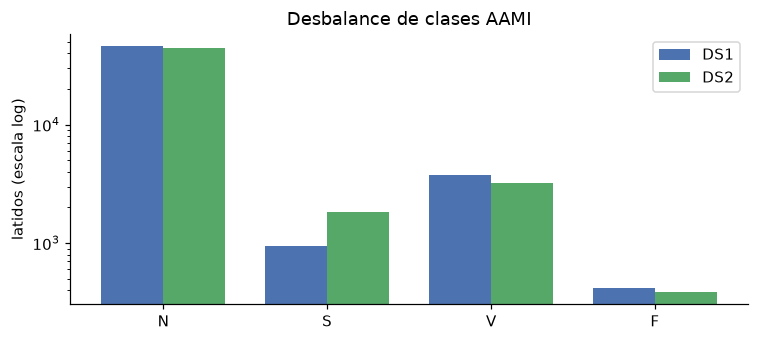

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(config.CLASSES))
for i, s in enumerate(["DS1", "DS2"]):
    ax.bar(x + (i - 0.5) * 0.38, counts[s], width=0.38, label=s, color=["#4C72B0", "#55A868"][i])
ax.set_yscale("log"); ax.set_xticks(x, config.CLASSES); ax.set_ylabel("latidos (escala log)")
ax.set_title("Desbalance de clases AAMI"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "class_balance.png")

**Conclusiones:**

- Los conteos coinciden con los publicados por de Chazal et al. con una diferencia ≤ 42 latidos
  por clase: son el primer y último latido de cada registro (no tienen RR previo/siguiente) y
  ventanas cortadas en los bordes. El pipeline de extracción es correcto.
- **N es ~90 %** en ambos splits. Un clasificador que predice siempre N tiene ~90 % de
  exactitud y 0 % de sensibilidad para las arritmias: la exactitud no sirve como métrica principal.
- S es 1.9 % en DS1 pero 3.7 % en DS2; F es < 1 % en ambos.

## 3. ¿En qué pacientes viven las clases minoritarias?

In [5]:
per_rec = pd.crosstab([df.split, df.record], df.y).reindex(columns=config.CLASSES, fill_value=0)
# fracción de cada clase (dentro de su split) aportada por el registro
share = per_rec / per_rec.groupby(level="split").transform("sum")
for cls in ["S", "V", "F"]:
    top = share[cls].groupby(level=0, group_keys=False).nlargest(3)
    print(cls, {f"{s}/{r}": f"{v:.0%}" for (s, r), v in top.items()})

S {'DS1/209': '41%', 'DS1/201': '14%', 'DS1/207': '11%', 'DS2/232': '75%', 'DS2/222': '11%', 'DS2/202': '3%'}
V {'DS1/208': '26%', 'DS1/106': '14%', 'DS1/223': '12%', 'DS2/233': '26%', 'DS2/200': '26%', 'DS2/221': '12%'}
F {'DS1/208': '90%', 'DS1/223': '3%', 'DS1/205': '3%', 'DS2/213': '93%', 'DS2/233': '3%', 'DS2/210': '3%'}


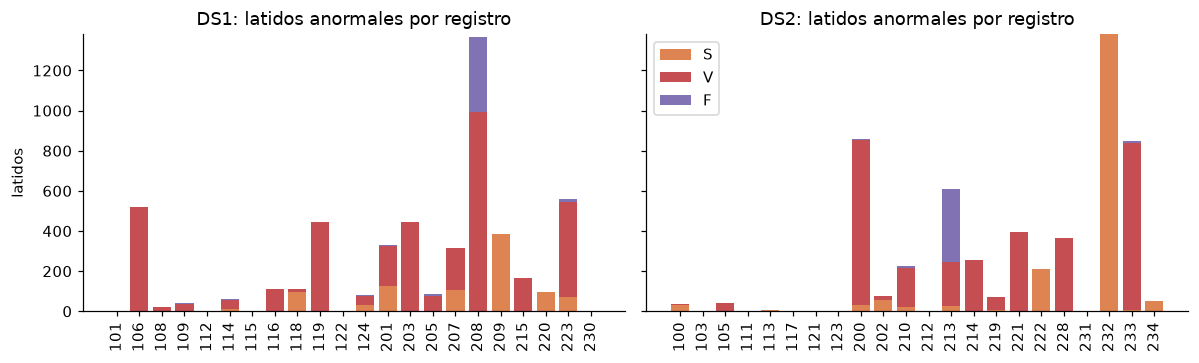

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, s in zip(axes, ["DS1", "DS2"]):
    t = per_rec.loc[s]
    bottom = np.zeros(len(t))
    for cls in ["S", "V", "F"]:
        ax.bar(t.index.astype(str), t[cls], bottom=bottom, color=COLORS[cls], label=cls)
        bottom += t[cls].values
    ax.set_title(f"{s}: latidos anormales por registro"); ax.tick_params(axis="x", rotation=90)
axes[0].set_ylabel("latidos"); axes[1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "abnormal_by_record.png")

**Conclusiones (clave para validar y evaluar):**

- **F está concentrada en un paciente por split**: el registro 208 aporta ~90 % de F en DS1 y el
  213 ~93 % en DS2. En la práctica, "detectar F" se aprende de *una persona* y se evalúa en
  *otra*. Con `GroupKFold` dentro de DS1, F aparecerá casi entera en un solo fold de validación:
  las métricas de F en validación van a ser muy ruidosas. Es una limitación a documentar.
- **S en DS2 es, sobre todo, el registro 232** (~75 % de los S de prueba). El F1 de S en DS2
  va a reflejar mayormente cómo le va al modelo con ese paciente. En DS1, S se reparte más
  (209, 201, 207, 118, 220).
- V está mejor distribuida (varios registros con cientos de latidos), así que su métrica será
  la más confiable.

## 4. Morfología: latido promedio por clase

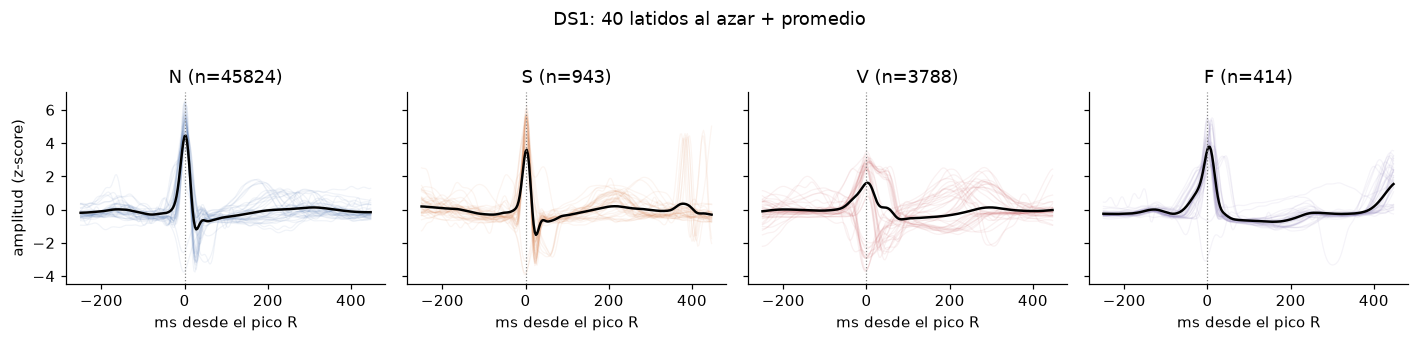

In [7]:
d1 = splits["ds1"]
t_ms = (np.arange(config.WINDOW) - config.PRE_SAMPLES) / config.FS * 1000
fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharey=True)
rng = np.random.default_rng(config.SEED)
for ax, cls in zip(axes, config.CLASSES):
    seg = d1["X"][d1["y"] == cls]
    for i in rng.choice(len(seg), 40, replace=False):
        ax.plot(t_ms, seg[i], color=COLORS[cls], alpha=0.08, lw=0.8)
    ax.plot(t_ms, seg.mean(0), color="k", lw=1.6)
    ax.axvline(0, color="grey", ls=":", lw=0.8)
    ax.set_title(f"{cls} (n={len(seg)})"); ax.set_xlabel("ms desde el pico R")
axes[0].set_ylabel("amplitud (z-score)")
fig.suptitle("DS1: 40 latidos al azar + promedio", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "beat_morphology.png", bbox_inches="tight")

**Conclusiones:**

- **V** tiene un QRS ancho y deforme, sin onda P: se distingue bien por morfología.
- **F** (fusión) es una mezcla entre N y V: morfología intermedia, por eso es difícil.
- **S** es casi idéntico a **N** en la ventana: la morfología sola no alcanza. Lo que distingue
  a un latido supraventricular prematuro es el **timing** (siguiente sección).

## 5. Ritmo: intervalos RR por clase

pre_rr  post_rr  pre_rr_over_local  post_over_pre_rr
split y                                                      
DS1   F   0.586    0.464              0.966             0.799
      N   0.756    0.736              1.002             0.993
      S   0.494    0.644              0.818             1.217
      V   0.519    0.861              0.733             1.673
DS2   F   0.553    0.553              0.999             1.000
      N   0.789    0.753              1.002             0.991
      S   0.722    0.744              0.728             1.042
      V   0.500    0.822              0.724             1.784

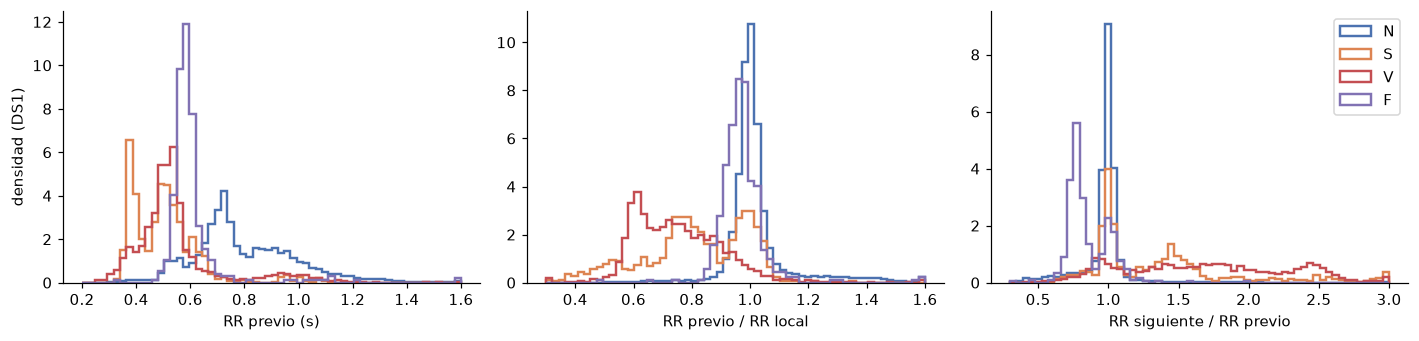

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
feats = [("pre_rr", "RR previo (s)", (0.2, 1.6)),
         ("pre_rr_over_local", "RR previo / RR local", (0.3, 1.6)),
         ("post_over_pre_rr", "RR siguiente / RR previo", (0.3, 3.0))]
for ax, (f, label, lim) in zip(axes, feats):
    for cls in config.CLASSES:
        v = df.loc[(df.split == "DS1") & (df.y == cls), f]
        ax.hist(v.clip(*lim), bins=60, range=lim, density=True, histtype="step", lw=1.6,
                color=COLORS[cls], label=cls)
    ax.set_xlabel(label)
axes[0].set_ylabel("densidad (DS1)"); axes[-1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "rr_by_class.png")

df.groupby(["split", "y"])[RR_FEATURE_NAMES].median().round(3)

In [9]:
premature = df.pre_rr_over_local < 0.85
print("fracción de latidos con RR previo < 85 % del RR local:")
print(premature.groupby([df.split, df.y]).mean().unstack().round(3)[config.CLASSES])

s = df[df.y == "S"]
print("\nS: RR previo absoluto (mediana, s) — registro 232 vs resto")
print(s.assign(r232=s.record == 232).groupby(["split", "r232"]).pre_rr.median().round(3))

fracción de latidos con RR previo < 85 % del RR local:
y          N      S      V      F
split                            
DS1    0.022  0.565  0.750  0.019
DS2    0.037  0.801  0.828  0.008

S: RR previo absoluto (mediana, s) — registro 232 vs resto
split  r232 
DS1    False    0.494
DS2    False    0.483
       True     0.731
Name: pre_rr, dtype: float32


**Conclusiones:**

- **S y V son prematuros**: su RR previo es mucho menor que el RR local (más de la mitad de los
  S y ~75–80 % de los V quedan por debajo del 85 %, contra ~2–4 % de los N).
- **V tiene pausa compensatoria**: RR siguiente / RR previo ≈ 1.7, más marcada que en S (≈ 1.0–1.2).
- **F no es prematuro** (cociente ≈ 1): se detecta por morfología, no por ritmo.
- **El RR absoluto no generaliza entre pacientes.** La mediana del RR previo de S cambia mucho
  entre DS1 y DS2 porque el registro 232 es bradicárdico: sus S prematuros tienen RR absolutos
  que en otro paciente serían normales. Los **cocientes** (RR previo / RR local) son estables
  entre splits. Esto justifica usar features relativas y no confiar solo en `pre_rr`.

## 6. Ruido y deriva de línea base

In [10]:
rows = []
for r in config.DS1 + config.DS2:
    rec = load_record(r)
    f, p = welch(rec.signal, rec.fs, nperseg=4096)
    rows.append({"record": r, "split": "DS1" if r in config.DS1 else "DS2",
                 "potencia <0.5 Hz (%)": 100 * p[f < 0.5].sum() / p.sum(),
                 "potencia >40 Hz (%)": 100 * p[f > 40].sum() / p.sum(),
                 "anotaciones de ruido (~)": int((rec.ann_symbols == "~").sum())})
noise = pd.DataFrame(rows).set_index("record").round(2)
noise.sort_values("anotaciones de ruido (~)", ascending=False).head(8)

,split,potencia <0.5 Hz (%),potencia >40 Hz (%),anotaciones de ruido (~)
record,,,,
105,DS2,15.32,0.18,88
203,DS1,24.18,0.34,57
200,DS2,4.93,0.36,43
108,DS1,62.14,0.42,41
232,DS2,10.04,0.44,35
106,DS1,4.71,0.55,30
215,DS1,2.38,0.65,30
208,DS1,15.99,0.24,24


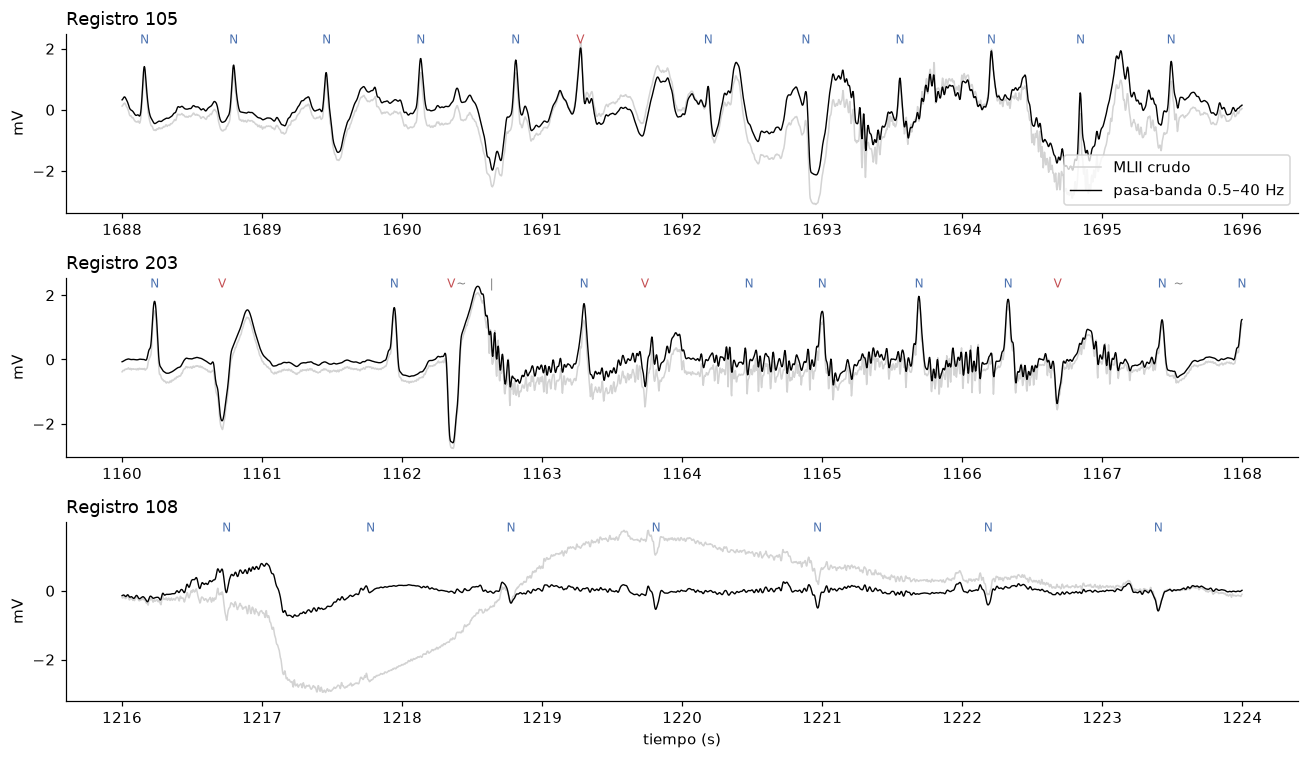

In [11]:
from scipy.signal import butter, filtfilt

def worst_window(rec, kind, win_s=8):
    """Inicio (s) de la ventana de 8 s con más ruido de alta frecuencia o más deriva."""
    x, fs, n = rec.signal, rec.fs, int(win_s * rec.fs)
    if kind == "hf":  # energía > 25 Hz
        b, a = butter(4, 25 / (fs / 2), btype="high")
        score = [np.std(filtfilt(b, a, x)[i:i + n]) for i in range(0, len(x) - n, n)]
    else:  # excursión de la línea base (< 0.5 Hz)
        base = x - bandpass(x, fs)
        score = [np.ptp(base[i:i + n]) for i in range(0, len(x) - n, n)]
    return int(np.argmax(score)) * win_s

fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, (r, kind) in zip(axes, [(105, "hf"), (203, "hf"), (108, "wander")]):
    rec = load_record(r)
    start_s = worst_window(rec, kind)
    sl = slice(int(start_s * rec.fs), int((start_s + 8) * rec.fs))
    t = np.arange(sl.start, sl.stop) / rec.fs
    ax.plot(t, rec.signal[sl], color="lightgray", lw=1, label="MLII crudo")
    ax.plot(t, bandpass(rec.signal, rec.fs)[sl], color="k", lw=0.9, label="pasa-banda 0.5–40 Hz")
    m = (rec.ann_samples >= sl.start) & (rec.ann_samples < sl.stop)
    for s_, sym in zip(rec.ann_samples[m], rec.ann_symbols[m]):
        ax.annotate(sym, (s_ / rec.fs, ax.get_ylim()[1]), ha="center", va="top", fontsize=8,
                    color=COLORS.get(config.AAMI_MAP.get(sym, ""), "grey"))
    ax.set_title(f"Registro {r}", loc="left"); ax.set_ylabel("mV")
axes[0].legend(loc="lower right"); axes[-1].set_xlabel("tiempo (s)")
fig.tight_layout(); fig.savefig(FIG_DIR / "noise_examples.png")

**Conclusiones:**

- **105 (DS2) y 203 (DS1)** tienen la mayor cantidad de segmentos anotados como ruido; 108 tiene
  la mayor fracción de potencia bajo 0.5 Hz (deriva de línea base).
- En 108 el pasa-banda 0.5–40 Hz con `filtfilt` elimina una deriva de ~3 mV y conserva la
  posición del pico R (fase cero), pero un salto brusco de la línea base (movimiento de
  electrodo) deja un transitorio residual de ~1 s.
- En 105 y 203 el ruido está **dentro de la banda del QRS**: ningún filtro lineal lo quita sin
  deformar el latido. Ahí el modelo puede fallar, y es la razón del chequeo de calidad de
  señal (REQ-005) en la API.
- Es esperable que 105 sea un registro con muchos falsos positivos en DS2.

## Resumen para las siguientes fases

| Hallazgo | Consecuencia |
|---|---|
| N ≈ 90 % | Métricas por clase (Se, +P, F1 macro); pesos de clase |
| S ≈ N en morfología, pero prematuro | Features RR obligatorias, sobre todo cocientes |
| RR absoluto cambia entre pacientes (232) | Priorizar features relativas; esperar caída de S en DS2 |
| F concentrada en 208 / 213 | Métricas de F poco confiables; documentar como limitación |
| S de DS2 ≈ registro 232 | Analizar el rendimiento por registro, no solo agregado |
| Ruido en 105, 203; deriva en 108 | Chequeo de calidad en la API; revisar errores por registro |